In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anweshaaa28/papers/paper-waste-why-it-matters-how-to-reduce-it-the-reel-talk-313906_1024x1024.webp
/kaggle/input/datasets/anweshaaa28/plastic/plastic.jpg
/kaggle/input/datasets/anweshaaa28/clothes/clothes.jpg
/kaggle/input/datasets/phenomsg/waste-classification/Organic/Organic/kitchen_waste/scandinavian-kitchen.jpg
/kaggle/input/datasets/phenomsg/waste-classification/Organic/Organic/kitchen_waste/1595698103_herbs-in-pots-istock-456025839.gif
/kaggle/input/datasets/phenomsg/waste-classification/Organic/Organic/kitchen_waste/foodwaste-683x1024.jpg
/kaggle/input/datasets/phenomsg/waste-classification/Organic/Organic/kitchen_waste/Plant-based-functional-food-ingredients-scrutinised-in-Pro-Enrich-project.jpg
/kaggle/input/datasets/phenomsg/waste-classification/Organic/Organic/kitchen_waste/Comparison-of-the-food-waste-estimated-using-the-MFA-approach-for-different-food-groups.png
/kaggle/input/datasets/phenomsg/waste-classification/Organic/Organic/kitchen_waste/pit-co

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-02-28 16:08:22.542594: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772294902.766939      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772294902.833946      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772294903.354696      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772294903.354749      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772294903.354752      55 computation_placer.cc:177] computation placer alr

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale = 1/255, shear_range = 0.2, zoom_range = 0.2,
                               brightness_range = (0.8, 1.2), horizontal_flip=True,validation_split=0.2)

train_data = datagen.flow_from_directory(
    "/kaggle/input/datasets/phenomsg/waste-classification",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset='training' 
)
val_data = datagen.flow_from_directory(
    "/kaggle/input/datasets/phenomsg/waste-classification",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset='validation' 
)

Found 2309 images belonging to 4 classes.
Found 575 images belonging to 4 classes.


In [3]:
from tensorflow.keras.applications.vgg16 import VGG16
vgg16 = VGG16(input_shape = (224, 224, 3), weights = "imagenet", include_top = False)

I0000 00:00:1772294928.872260      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772294928.878261      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
for layer in vgg16.layers:
  if "block5" in layer.name:
    layer.trainable = True
  else: layer.trainable = False


In [7]:
from tensorflow.keras import layers
import tensorflow as tf
x = vgg16.output
x = layers.GlobalAveragePooling2D()(x)

#ANN layer 1
x=layers.Dense(512,activation="relu")(x)
x=layers.Dropout(0.5)(x)

#ANN layer 2
x=layers.Dense(256,activation="relu")(x)
x=layers.Dropout(0.3)(x)

#Output layer
prediction=layers.Dense(4,activation="softmax")(x)

model=tf.keras.models.Model(inputs=vgg16.input,outputs=prediction)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,109,700 (57.64 MB)

 Trainable params: 7,474,436 (28.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
result = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    steps_per_epoch=len(train_data),
    validation_steps=len(val_data),
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1772294970.798141     131 service.cc:152] XLA service 0x7ac740005500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772294970.798177     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772294970.798183     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772294971.439096     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/73 ━━━━━━━━━━━━━━━━━━━━ 23:02 19s/step - accuracy: 0.2188 - loss: 1.8524

I0000 00:00:1772294986.671255     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/73 ━━━━━━━━━━━━━━━━━━━━ 51s 876ms/step - accuracy: 0.2650 - loss: 1.5523

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


57/73 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3071 - loss: 1.4462

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


73/73 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.3187 - loss: 1.4268 - val_accuracy: 0.4296 - val_loss: 1.2993
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.5166 - loss: 1.1447 - val_accuracy: 0.5130 - val_loss: 1.2758
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.6140 - loss: 0.9778 - val_accuracy: 0.5148 - val_loss: 1.3046
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.6844 - loss: 0.8065 - val_accuracy: 0.5391 - val_loss: 1.3411
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.7354 - loss: 0.6790 - val_accuracy: 0.5096 - val_loss: 1.2517
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.7660 - loss: 0.6293 - val_accuracy: 0.5548 - val_loss: 1.3717
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.7964 - loss: 0.5551 - val_accuracy: 0.4922 - val_loss: 1.4342
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8119 - loss: 0.5049 - val_accuracy: 0.5009 - val_loss: 1.2747
Ep

In [12]:
from tensorflow.keras.preprocessing import image
output_class = ["Hazardous","Non-Recyclable","Organic","Recyclable"]
def waste_prediction(new_image):
  test_image = image.load_img(new_image, target_size = (224,224))
  plt.axis("off")
  plt.imshow(test_image)
  plt.show()

  test_image = image.img_to_array(test_image) / 255
  test_image = np.expand_dims(test_image, axis=0)

  predicted_array = model.predict(test_image)
  predicted_value = output_class[np.argmax(predicted_array)]
  predicted_accuracy = round(np.max(predicted_array) * 100, 2)

  print("Your waste material is ", predicted_value, " with ", predicted_accuracy, " % accuracy")

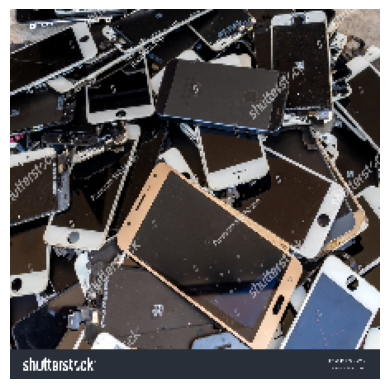

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Your waste material is  Hazardous  with  99.79  % accuracy


In [13]:
waste_prediction("/kaggle/input/datasets/phenomsg/waste-classification/Hazardous/Hazardous/e-waste/-august-heap-of-broken-smartphone-screen-e-waste-electronic-waste-1100705909 - Copy.jpg")

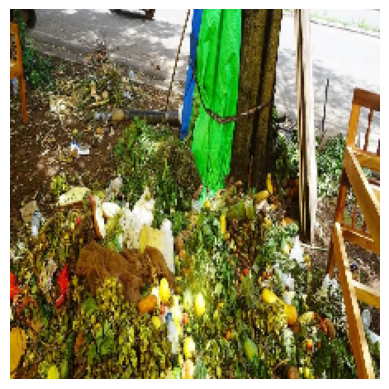

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Your waste material is  Organic  with  65.27  % accuracy


In [14]:
waste_prediction("/kaggle/input/datasets/phenomsg/waste-classification/Organic/Organic/food_scraps/0.07700600_1571147766_14.jpg")

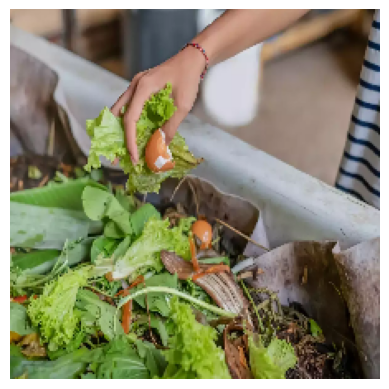

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Your waste material is  Organic  with  59.88  % accuracy


In [15]:
waste_prediction("/kaggle/input/datasets/phenomsg/waste-classification/Organic/Organic/food_scraps/97085579.jpg")


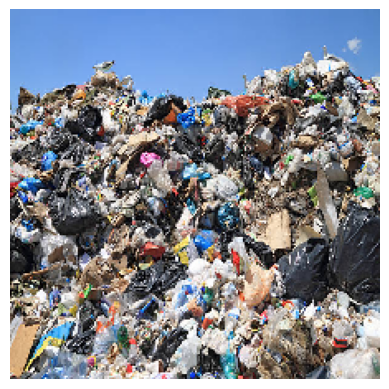

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Your waste material is  Non-Recyclable  with  42.44  % accuracy


In [19]:
waste_prediction("/kaggle/input/datasets/anweshaaa28/plastic/plastic.jpg")


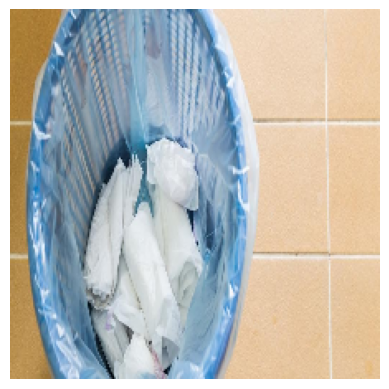

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Your waste material is  Non-Recyclable  with  94.99  % accuracy


In [18]:
waste_prediction("/kaggle/input/datasets/phenomsg/waste-classification/Non-Recyclable/Non-Recyclable/sanitary_napkin/0.57118300_1559106463_sanitary_waste_gettyimages-.jpg")

In [20]:
model.save("waste_classification_model.h5")